Q3
-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Q4
-

In [2]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')

In [3]:
gdp_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


Q5
    8,456 rows, 4 Columns;
    Data Types for columns are:
        Country or Area = object
        Year = int64
        Value = float64
        Value Footnotes = float64  
-

In [4]:
print(gdp_df.shape)

(8465, 4)


In [5]:
gdp_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

Q6
-

In [6]:
gdp_df = gdp_df.drop(columns = "Value Footnotes")

In [7]:
gdp_df = gdp_df.rename(columns={"Country or Area":"Country","Value":"GDP_Per_Capita"})

Q7a
    How many countries have data for all years? - 226
-

In [8]:
total_years = gdp_df['Year'].nunique()

In [9]:
total_years

35

In [10]:
country_year_counts = gdp_df.groupby('Country')['Year'].nunique()
country_year_counts

Country
Afghanistan                    24
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
                               ..
Virgin Islands (US)            21
West Bank and Gaza             31
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 247, dtype: int64

In [11]:
countries_with_all_years = country_year_counts[country_year_counts == total_years]
countries_with_all_years

Country
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
Andorra                        35
                               ..
Vanuatu                        35
Viet Nam                       35
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 226, dtype: int64

Q7b
    Which countries are missing many years of data?
        Afghanistan                  24
        Bhutan                       34
        Cayman Islands               18
        CuraÃ§ao                     25
        Djibouti                     12
        Faroe Islands                17
        Greenland                    34
        Kosovo                       17
        Lebanon                      34
        Montenegro                   28
        Palau                        34
        San Marino                   27
        Serbia                       30
        Sint Maarten (Dutch part)    16
        Somalia, Fed. Rep.           34
        Syrian Arab Republic         33
        Tonga                        34
        Turks and Caicos Islands     18
        Tuvalu                       34
        Virgin Islands (US)          21
        West Bank and Gaza           31
-

In [12]:
countries_not_with_all_years = country_year_counts[country_year_counts != total_years]
countries_not_with_all_years

Country
Afghanistan                  24
Bhutan                       34
Cayman Islands               18
CuraÃ§ao                     25
Djibouti                     12
Faroe Islands                17
Greenland                    34
Kosovo                       17
Lebanon                      34
Montenegro                   28
Palau                        34
San Marino                   27
Serbia                       30
Sint Maarten (Dutch part)    16
Somalia, Fed. Rep.           34
Syrian Arab Republic         33
Tonga                        34
Turks and Caicos Islands     18
Tuvalu                       34
Virgin Islands (US)          21
West Bank and Gaza           31
Name: Year, dtype: int64

Q7c
    The number of countries observed per year increased from 1990 to 2013, where 247 countries are included. This number went down in 2023 and 2024. Fluctuations in the number of countries in the data set can happen when instability disrupts data collection or nation definitions or groupings change.
-

In [13]:
gdp_df.groupby(gdp_df['Year']).size()

Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    243
2008    245
2009    246
2010    246
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236
dtype: int64

Q8
-

Q8 Answer - The histogram lends itself well to seeing the distribution of the number of countries across the GDP spectrum as does the density plot.
    The histogram is more categorical - meaning it's easiest to look at a certain GDP level and answer how many countries are around that level.

In [14]:
gdp_df_2020 = gdp_df.loc[gdp_df['Year'] == 2020]
gdp_df_2020

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


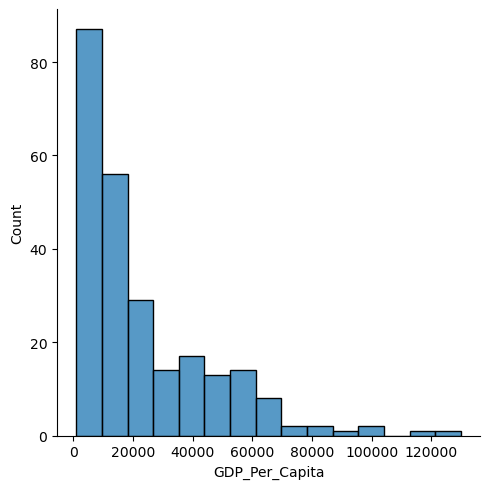

In [15]:
sns.displot(data=gdp_df[gdp_df['Year'] == 2020], x="GDP_Per_Capita")

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

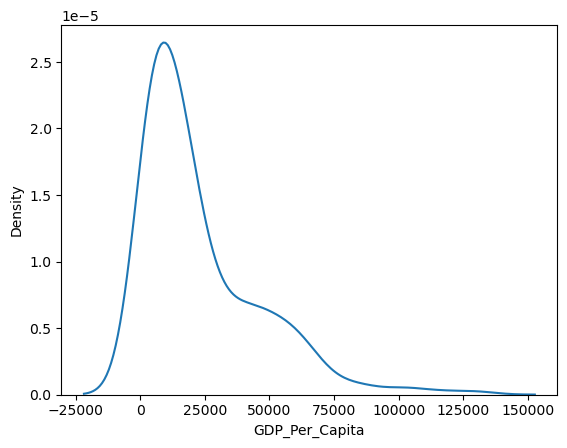

In [16]:
sns.kdeplot(gdp_df_2020['GDP_Per_Capita'])

<Axes: ylabel='GDP_Per_Capita'>

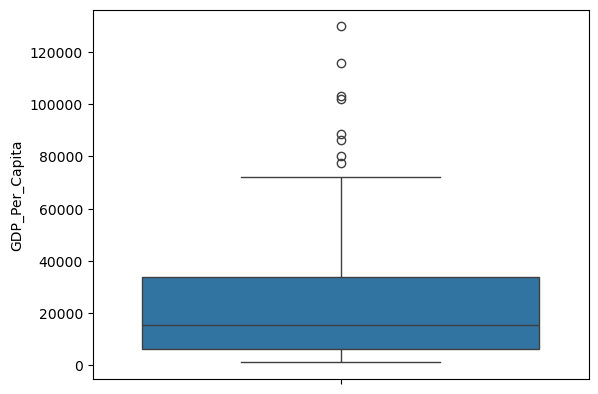

In [17]:
sns.boxplot(y=gdp_df_2020["GDP_Per_Capita"] )

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

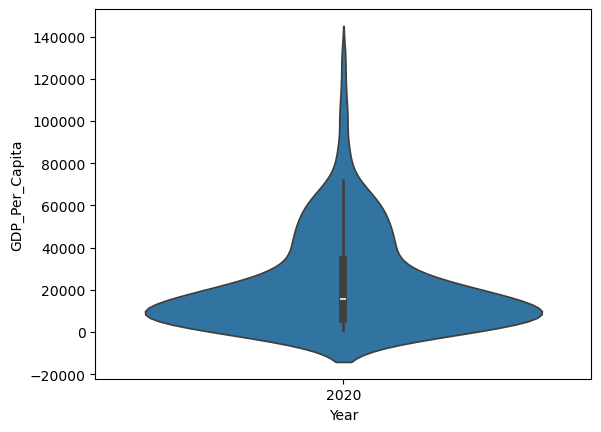

In [18]:
sns.violinplot(x=gdp_df_2020["Year"], y=gdp_df_2020["GDP_Per_Capita"])

Q9 - GDP Percapita Income in 2020 = 15,399
-

In [19]:
gdp_df_2020['GDP_Per_Capita'].median()

15399.308958012449

Q10
-

In [20]:
decades_list = [1990,2000,2010,2020]
gdp_decades = gdp_df.loc[gdp_df.Year.isin(decades_list)]

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

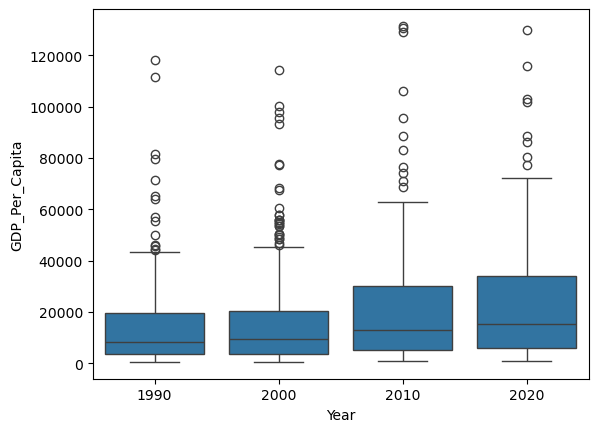

In [21]:
sns.boxplot(y="GDP_Per_Capita",x="Year", data=gdp_decades)

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

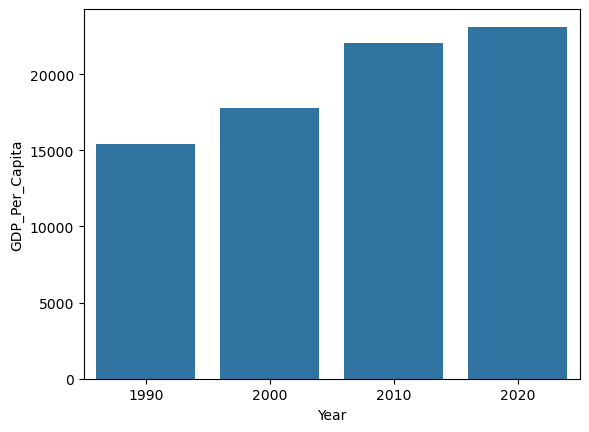

In [22]:
sns.barplot(x="Year", y="GDP_Per_Capita", data=gdp_decades, errorbar = None)

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

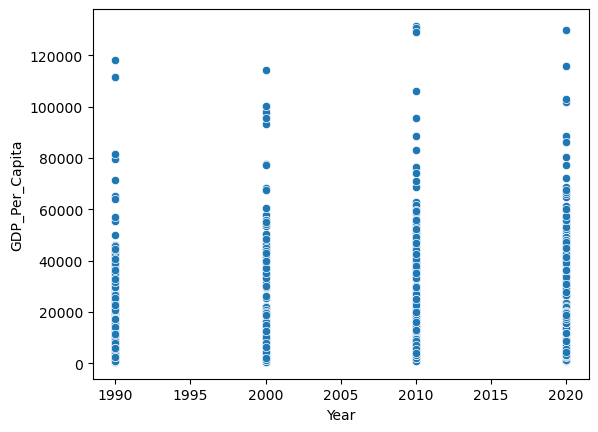

In [23]:
sns.scatterplot(y = "GDP_Per_Capita", x="Year", data=gdp_decades)

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

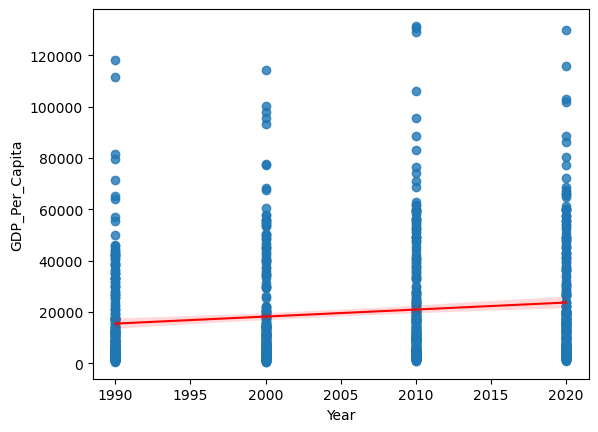

In [24]:
sns.regplot(y = "GDP_Per_Capita", x="Year", data=gdp_decades, line_kws={"color": "red", "linewidth": 1.5})

Q11
    Which country was the first to have a GDP per capita greater than $100,000?
UAI & Brunei
-

In [25]:
gdp_df.loc[gdp_df['GDP_Per_Capita']>=100000].sort_values(by = 'Year').head(2)

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.04689
1037,Brunei Darussalam,1990,118163.68337


Q12a - Which country had the highest GDP per capita in 2020?
Luxembourg
-

In [26]:
gdp_df.loc[gdp_df['Year']==2020].sort_values(by = 'GDP_Per_Capita', ascending = False).head(1)

,Country,Year,GDP_Per_Capita
4629,Luxembourg,2020,129865.629988


Q12b - Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.
-

In [27]:
gdp_df_lux = gdp_df.loc[gdp_df['Country']=='Luxembourg']

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

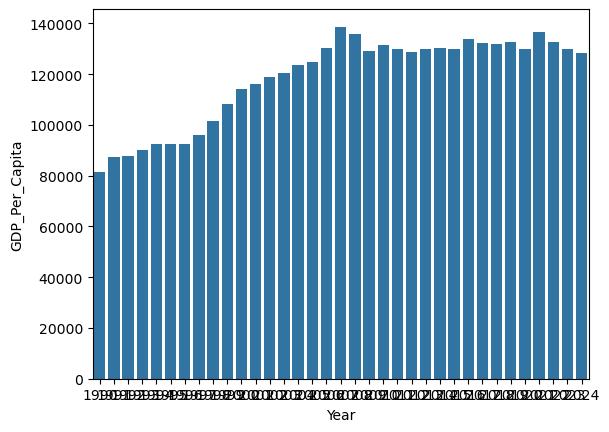

In [28]:
sns.barplot(data = gdp_df_lux, y='GDP_Per_Capita', x='Year')

Q13a
Which country had the lowest GDP per capita in 2020?
Burundi
-

In [29]:
gdp_df.loc[gdp_df['Year']==2020].sort_values(by = 'GDP_Per_Capita').head(1)

,Country,Year,GDP_Per_Capita
1112,Burundi,2020,1030.770264


Q13b
Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.
-

In [30]:
gdp_df_burundi = gdp_df.loc[gdp_df['Country']=='Burundi']

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

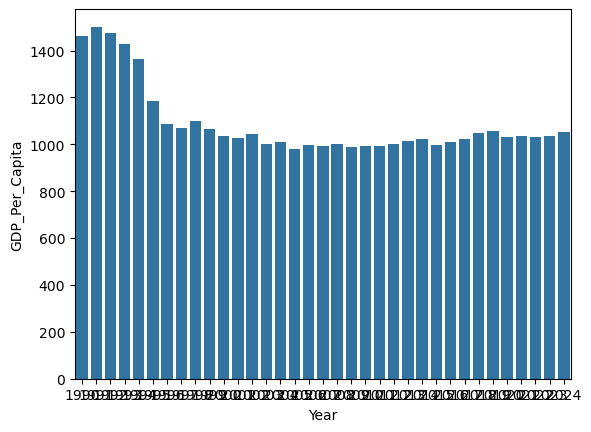

In [31]:
sns.barplot(data = gdp_df_burundi, y='GDP_Per_Capita', x='Year')

Q13C
**Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?
-

Q14
-

In [32]:
internet_df = pd.read_csv('../data/internet_use_v2.csv')
internet_df

,Country or Area,Year,Value,Value Footnotes,Footnotes
0,Afghanistan,2019,17.600000,1,Asia Foundation. ITU estimate.
1,Afghanistan,2018,16.800000,2,Asia Foundation. ITU estimate.
2,Afghanistan,2017,13.500000,3,"Asia Foundation, ITU estimate."
3,Afghanistan,2016,11.000000,4,ITU estimate
4,Afghanistan,2015,8.260000,4,ITU estimate
...,...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN,NaN
6079,Zimbabwe,1996,0.016790,NaN,NaN
6080,Zimbabwe,1995,0.007684,NaN,NaN
6081,Zimbabwe,1994,0.001739,NaN,NaN


In [33]:
internet_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes     object
Footnotes           object
dtype: object

Q15.
    Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.
-

In [34]:
internet_df = internet_df.drop(columns = ["Value Footnotes","Footnotes"])

In [35]:
internet_df = internet_df.rename(columns={"Country or Area":"Country","Value":"Internet_Users_Pct"})
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


Q16. 16-Look at the number of observations in this dataset per year. What do you notice?

The number of obervations (countries reporting) changes quite a bit over the years. It's odd that 1990 had a high number of countries reporting. It happens to be the same as the number of countries that provided GDP Per Capita Data.
-

In [41]:
internet_df_yearly = internet_df.groupby('Year')['Country'].nunique()
internet_df_yearly


Year
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: Country, dtype: int64

Q17. What is the first year to have a non-zero internet users percentage value?
-

In [ ]:
internet_df_iup = 